# 📊 EDA: Tingkat Pengangguran Terbuka (TPT) Usia 35–45 Tahun di Indonesia
### *Krisis Ketenagakerjaan Tersembunyi di Balik Angka yang Tampak Kecil*

---

**Penulis:** Wahid Setio Darmadi\
**GitHub:** github.com/whddarmadi\
**Tanggal:** Juni 2026

**Sumber Data:**
- BPS RI — Tingkat Pengangguran Terbuka Berdasarkan Kelompok Umur (2025)
- BPS RI — Penduduk 15 Tahun ke Atas Menurut Jenis Kegiatan (Februari 2026)

**Referensi Regulasi & Konteks:**
- UUD 1945 Pasal 27 ayat (2)
- UU No. 13 Tahun 2003 tentang Ketenagakerjaan
- UU No. 39 Tahun 1999 tentang Hak Asasi Manusia
- SE Menaker No. M/6/HK.04/V/2025 tentang Larangan Diskriminasi dalam Proses Rekrutmen
- PP No. 51 Tahun 2023 tentang Pengupahan

---

### 🎯 Latar Belakang

Dalam diskursus ketenagakerjaan Indonesia, perhatian kebijakan hampir selalu tertuju pada pengangguran usia muda. Namun ada kelompok yang secara sistematis tersingkir dari pasar kerja formal namun jarang disorot: **penduduk usia 35–45 tahun.**

Kelompok ini menghadapi paradoks ganda:
- TPT-nya **rendah secara persentase** — sehingga tidak terlihat sebagai prioritas kebijakan
- Namun populasinya **sangat besar** — sehingga secara absolut dampaknya sangat signifikan
- Mayoritas sudah **berkeluarga dengan tanggungan** — sehingga dampak sosialnya berlipat ganda
- Menghadapi **diskriminasi usia sistemik** di pasar kerja — meski regulasi melarangnya

EDA ini bertujuan memotret realita tersebut secara berbasis data, sekaligus menyuarakan konteks sosial dan hukum yang melatarbelakanginya.

---

### 📌 Struktur Analisis
1. Persiapan Data
2. Analisis TPT Usia 35–45 Nasional
3. Konteks Hukum: Regulasi vs Realita
4. Analisis Upah: UMP vs Daya Beli Riil
5. Analisis Historis: UMR vs Harga Emas
6. Proyeksi Dampak Jangka Panjang
7. Opini Penulis
8. Ringkasan & Rekomendasi

---
## Bagian 1: Persiapan Data

In [1]:
# Mount Google Drive (jalankan cell ini pertama kali di Google Colab)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Sesuaikan BASE_PATH dengan lokasi folder project kamu di Google Drive
BASE_PATH = '/content/drive/MyDrive/Colab Project/EDA_TPT_Nasional_3545'
OUTPUT_PATH = '/content/drive/MyDrive/Colab Project/EDA_TPT_Nasional_3545/output'

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
print('Google Drive berhasil di-mount')
print(f'BASE_PATH : {BASE_PATH}')
print(f'OUTPUT_PATH: {OUTPUT_PATH}')

Google Drive berhasil di-mount
BASE_PATH : /content/drive/MyDrive/Colab Project/EDA_TPT_Nasional_3545
OUTPUT_PATH: /content/drive/MyDrive/Colab Project/EDA_TPT_Nasional_3545/output


In [3]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Library berhasil diimport')

Library berhasil diimport


In [4]:
# Load dataset
tpt_raw = pd.read_csv(BASE_PATH + '/data/tpt_nasional_2025.csv')
ak_raw = pd.read_csv(BASE_PATH + '/data/penduduk_15plus_nasional_2026.csv')

print('Dataset berhasil dimuat')
print(f'  tpt_raw : {tpt_raw.shape}')
print(f'  ak_raw  : {ak_raw.shape}')

Dataset berhasil dimuat
  tpt_raw : (11, 2)
  ak_raw  : (11, 2)


In [5]:
# Cek struktur data
print('=== TPT NASIONAL 2025 ===')
print(tpt_raw.to_string(index=False))
print()
print('=== ANGKATAN KERJA NASIONAL (Feb 2026) ===')
print(ak_raw.to_string(index=False))

=== TPT NASIONAL 2025 ===
Kelompok Umur  Tingkat Pengangguran Terbuka (%)
        15-19                             23.34
        20-24                             14.35
        25-29                              6.67
        30-34                              3.47
        35-39                              2.35
        40-44                              1.86
        45-49                              1.96
        50-54                              1.74
        55-59                              1.73
          60+                              1.71
    Rata-Rata                              4.85

=== ANGKATAN KERJA NASIONAL (Feb 2026) ===
                        Jenis Kegiatan  Februari 2026
     Penduduk Berumur 15 Tahun Ke Atas   219538628.00
                        Angkatan Kerja   154911235.00
Tingkat Partisipasi Angkatan Kerja (%)          70.56
                               Bekerja   147667630.00
                  Pengangguran Terbuka     7243605.00
      Tingkat Pengangguran Ter

In [6]:
# Cek kualitas data
print('=== MISSING VALUES ===')
print('TPT Nasional:')
print(tpt_raw.isnull().sum())
print()
print('Angkatan Kerja:')
print(ak_raw.isnull().sum())

print()
print('=== TIPE DATA ===')
print(tpt_raw.dtypes)

print()
print('=== STATISTIK DESKRIPTIF ===')
print(tpt_raw.describe())

=== MISSING VALUES ===
TPT Nasional:
Kelompok Umur                       0
Tingkat Pengangguran Terbuka (%)    0
dtype: int64

Angkatan Kerja:
Jenis Kegiatan    0
Februari 2026     0
dtype: int64

=== TIPE DATA ===
Kelompok Umur                        object
Tingkat Pengangguran Terbuka (%)    float64
dtype: object

=== STATISTIK DESKRIPTIF ===
       Tingkat Pengangguran Terbuka (%)
count                         11.000000
mean                           5.820909
std                            6.926658
min                            1.710000
25%                            1.800000
50%                            2.350000
75%                            5.760000
max                           23.340000


In [7]:
# Transformasi data
tpt = tpt_raw[tpt_raw['Kelompok Umur'] != 'Rata-Rata'].copy()
tpt.columns = ['kelompok_umur', 'tpt_persen']
tpt['is_fokus'] = tpt['kelompok_umur'].isin(['35-39', '40-44'])
tpt['kategori'] = tpt['kelompok_umur'].apply(lambda x:
    'Usia Muda (15-29)' if x in ['15-19','20-24','25-29']
    else ('Fokus: 35-44' if x in ['35-39','40-44']
    else ('Transisi (30-34)' if x == '30-34'
    else 'Senior (45+)')))

rata_rata = float(
    tpt_raw[tpt_raw['Kelompok Umur'] == 'Rata-Rata']
    ['Tingkat Pengangguran Terbuka (%)'].values[0]
)

ak = dict(zip(ak_raw['Jenis Kegiatan'], ak_raw['Februari 2026']))

print('Transformasi selesai')
print(f'  Rata-rata TPT nasional : {rata_rata}%')
print(f'  Total pengangguran     : {int(ak["Pengangguran Terbuka"]):,} orang')
print(f'  Total angkatan kerja   : {int(ak["Angkatan Kerja"]):,} orang')

Transformasi selesai
  Rata-rata TPT nasional : 4.85%
  Total pengangguran     : 7,243,605 orang
  Total angkatan kerja   : 154,911,235 orang


---
## Bagian 2: Analisis TPT Usia 35–45 Nasional

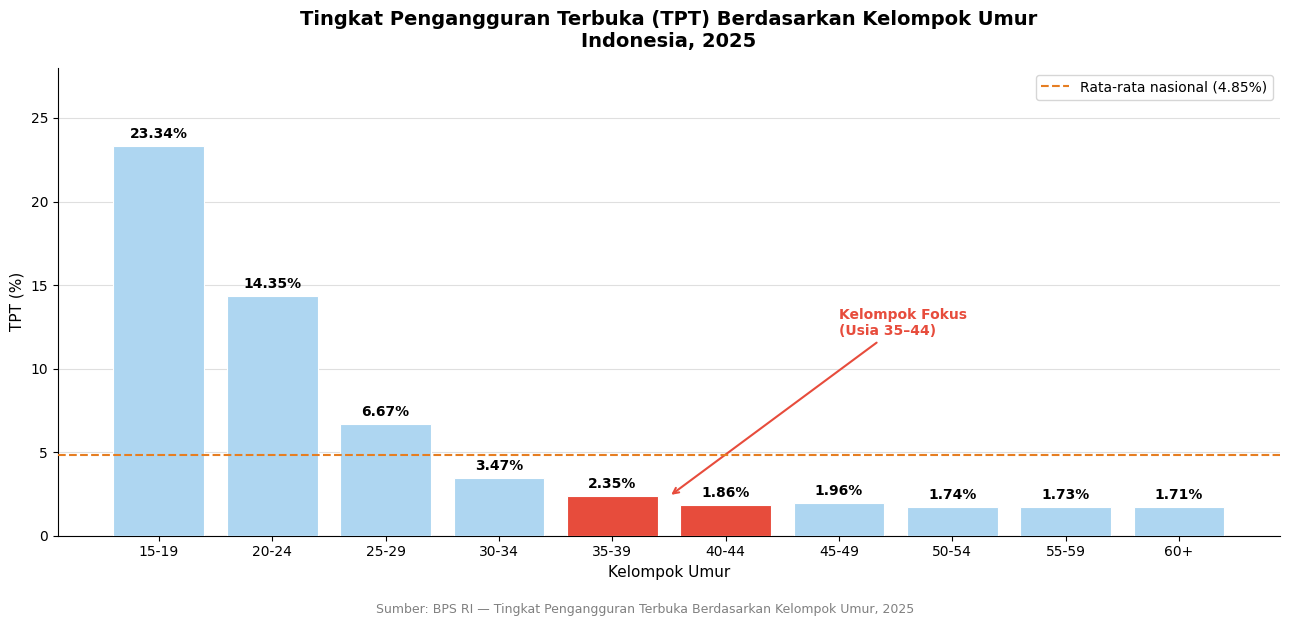

viz_01 tersimpan


In [8]:
# Visualisasi 1: TPT per kelompok umur
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#E74C3C' if f else '#AED6F1' for f in tpt['is_fokus']]
bars = ax.bar(tpt['kelompok_umur'], tpt['tpt_persen'],
              color=colors, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, tpt['tpt_persen']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=rata_rata, color='#E67E22', linestyle='--',
           linewidth=1.5, label=f'Rata-rata nasional ({rata_rata}%)', zorder=4)

ax.annotate('Kelompok Fokus\n(Usia 35–44)',
            xy=(4.5, 2.35), xytext=(6.0, 12),
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5),
            fontsize=10, color='#E74C3C', fontweight='bold')

ax.set_title(
    'Tingkat Pengangguran Terbuka (TPT) Berdasarkan Kelompok Umur\nIndonesia, 2025',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Kelompok Umur', fontsize=11)
ax.set_ylabel('TPT (%)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, 28)
ax.grid(axis='y', alpha=0.4, zorder=0)
plt.figtext(
    0.5, -0.03,
    'Sumber: BPS RI — Tingkat Pengangguran Terbuka Berdasarkan Kelompok Umur, 2025',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'viz_01_tpt_per_kelompok_umur.png', dpi=150, bbox_inches='tight')
plt.show()
print('viz_01 tersimpan')

In [9]:
# Estimasi jumlah absolut pengangguran usia 35-44
total_ak = int(ak['Angkatan Kerja'])
total_pengangguran = int(ak['Pengangguran Terbuka'])

# Asumsi: ~20% angkatan kerja berada di usia 35-44
# (berdasarkan struktur demografi Indonesia)
est_ak_3544 = total_ak * 0.20
est_pengangguran_3539 = est_ak_3544 * 0.5 * (2.35 / 100)
est_pengangguran_4044 = est_ak_3544 * 0.5 * (1.86 / 100)
est_total_3544 = est_pengangguran_3539 + est_pengangguran_4044

print('=== GAMBARAN ANGKATAN KERJA NASIONAL (Februari 2026) ===')
print(f'  Penduduk 15+        : {int(ak["Penduduk Berumur 15 Tahun Ke Atas"]):>15,} orang')
print(f'  Angkatan Kerja      : {total_ak:>15,} orang')
print(f'  Bekerja             : {int(ak["Bekerja"]):>15,} orang')
print(f'  Pengangguran Terbuka: {total_pengangguran:>15,} orang')
print(f'  TPT Nasional        : {ak["Tingkat Pengangguran Terbuka (%)"]:.2f}%')
print(f'  TPAK                : {ak["Tingkat Partisipasi Angkatan Kerja (%)"]:.2f}%')
print()
print('=== ESTIMASI PENGANGGURAN USIA 35–44 (NASIONAL) ===')
print(f'  Estimasi AK usia 35-44   : {est_ak_3544:>12,.0f} orang (~20% dari total AK)')
print(f'  Est. pengangguran 35-39  : {est_pengangguran_3539:>12,.0f} orang (TPT 2,35%)')
print(f'  Est. pengangguran 40-44  : {est_pengangguran_4044:>12,.0f} orang (TPT 1,86%)')
print(f'  Est. TOTAL usia 35-44    : {est_total_3544:>12,.0f} orang')
print(f'  Proporsi dari total      : {est_total_3544/total_pengangguran*100:.1f}%')
print()
print('Catatan: Estimasi berdasarkan asumsi distribusi 20% AK.')
print('Data mikro Sakernas diperlukan untuk angka yang lebih presisi.')

=== GAMBARAN ANGKATAN KERJA NASIONAL (Februari 2026) ===
  Penduduk 15+        :     219,538,628 orang
  Angkatan Kerja      :     154,911,235 orang
  Bekerja             :     147,667,630 orang
  Pengangguran Terbuka:       7,243,605 orang
  TPT Nasional        : 4.68%
  TPAK                : 70.56%

=== ESTIMASI PENGANGGURAN USIA 35–44 (NASIONAL) ===
  Estimasi AK usia 35-44   :   30,982,247 orang (~20% dari total AK)
  Est. pengangguran 35-39  :      364,041 orang (TPT 2,35%)
  Est. pengangguran 40-44  :      288,135 orang (TPT 1,86%)
  Est. TOTAL usia 35-44    :      652,176 orang
  Proporsi dari total      : 9.0%

Catatan: Estimasi berdasarkan asumsi distribusi 20% AK.
Data mikro Sakernas diperlukan untuk angka yang lebih presisi.


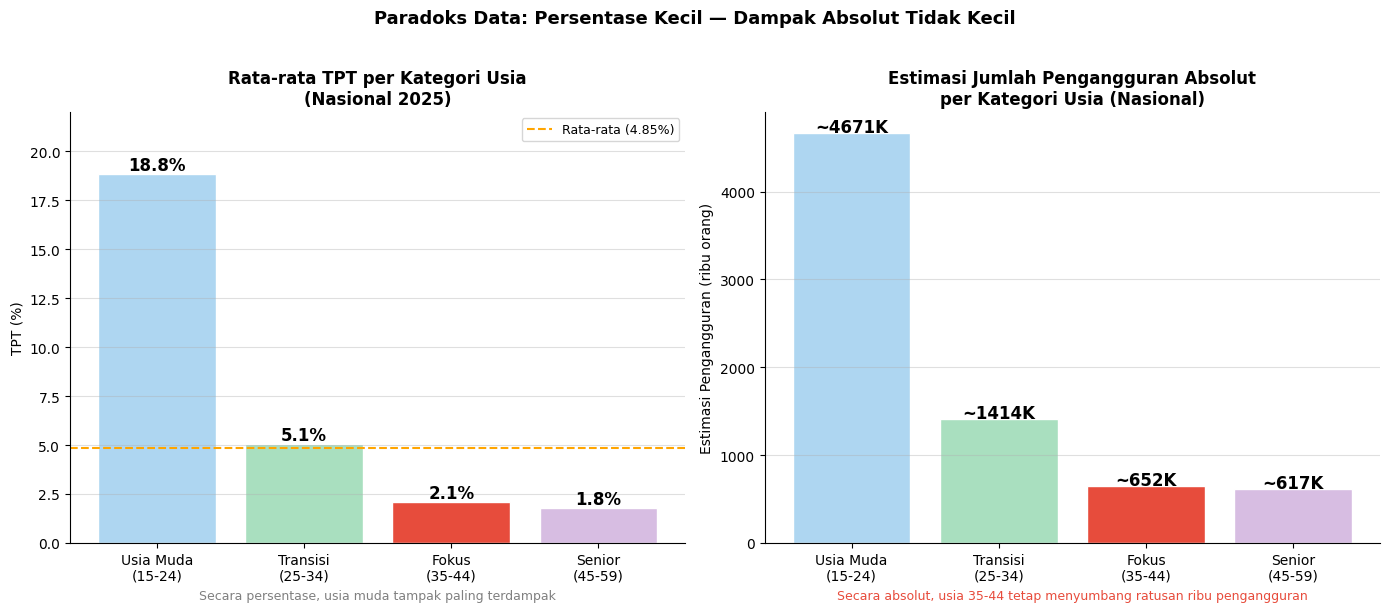

viz_02 tersimpan


In [10]:
# Visualisasi 2: Persentase vs Absolut
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Data per kategori besar
kat_label = ['Usia Muda\n(15-24)', 'Transisi\n(25-34)', 'Fokus\n(35-44)', 'Senior\n(45-59)']
tpt_per_kat = [
    tpt[tpt['kelompok_umur'].isin(['15-19','20-24'])]['tpt_persen'].mean(),
    tpt[tpt['kelompok_umur'].isin(['25-29','30-34'])]['tpt_persen'].mean(),
    tpt[tpt['kelompok_umur'].isin(['35-39','40-44'])]['tpt_persen'].mean(),
    tpt[tpt['kelompok_umur'].isin(['45-49','50-54','55-59'])]['tpt_persen'].mean()
]
warna_kat = ['#AED6F1', '#A9DFBF', '#E74C3C', '#D7BDE2']

# Panel kiri: TPT persen
bars = axes[0].bar(kat_label, tpt_per_kat, color=warna_kat, edgecolor='white')
for bar, val in zip(bars, tpt_per_kat):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].axhline(y=rata_rata, color='orange', linestyle='--',
                label=f'Rata-rata ({rata_rata}%)')
axes[0].set_title('Rata-rata TPT per Kategori Usia\n(Nasional 2025)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('TPT (%)')
axes[0].set_ylim(0, 22)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)
axes[0].text(0.5, -0.13,
             'Secara persentase, usia muda tampak paling terdampak',
             transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# Panel kanan: Estimasi absolut
est_ak_per_kat = total_ak * np.array([0.16, 0.18, 0.20, 0.22])
tpt_per_kat_arr = np.array(tpt_per_kat) / 100
est_abs = est_ak_per_kat * tpt_per_kat_arr

bars2 = axes[1].bar(kat_label, est_abs / 1000, color=warna_kat, edgecolor='white')
for bar, val in zip(bars2, est_abs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1000 + 5,
                 f'~{val/1000:.0f}K', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Estimasi Jumlah Pengangguran Absolut\nper Kategori Usia (Nasional)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Estimasi Pengangguran (ribu orang)')
axes[1].grid(axis='y', alpha=0.4)
axes[1].text(0.5, -0.13,
             'Secara absolut, usia 35-44 tetap menyumbang ratusan ribu pengangguran',
             transform=axes[1].transAxes, ha='center', fontsize=9, color='#E74C3C')

plt.suptitle('Paradoks Data: Persentase Kecil — Dampak Absolut Tidak Kecil',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'viz_02_paradoks_persen_vs_absolut.png', dpi=150, bbox_inches='tight')
plt.show()
print('viz_02 tersimpan')

---
## Bagian 3: Konteks Hukum — Regulasi vs Realita

In [11]:
# Ringkasan regulasi — disajikan sebagai tabel informatif
regulasi = pd.DataFrame({
    'Regulasi': [
        'UUD 1945 Pasal 27 ayat (2)',
        'UU No. 13/2003 Ketenagakerjaan Pasal 35 ayat (1)',
        'UU No. 39/1999 HAM Pasal 1 angka 3',
        'SE Menaker No. M/6/HK.04/V/2025',
        'Konvensi ILO No. 111 Tahun 1958'
    ],
    'Isi Pokok': [
        'Setiap WNI berhak atas pekerjaan dan penghidupan yang layak',
        'Pemberi kerja dilarang diskriminasi dalam rekrutmen',
        'Diskriminasi dilarang — namun usia belum masuk definisi eksplisit',
        'Larangan batas usia dalam rekrutmen kecuali pekerjaan dengan karakteristik khusus',
        'Negara wajib memastikan tidak ada diskriminasi dalam rekrutmen dan hubungan kerja'
    ],
    'Kekuatan Hukum': [
        'Konstitusi — mengikat',
        'UU — mengikat, namun penegakan lemah',
        'UU — sedang diuji di MK terkait usia',
        'Surat Edaran — tidak mengikat, imbauan',
        'Konvensi internasional — diratifikasi Indonesia'
    ],
    'Status': [
        'Berlaku',
        'Berlaku — minim penegakan',
        'Berlaku — sedang diuji MK',
        'Baru terbit Mei 2025',
        'Berlaku'
    ]
})

print('=== PETA REGULASI: LARANGAN DISKRIMINASI USIA DALAM REKRUTMEN ===')
print()
for _, row in regulasi.iterrows():
    print(f'[{row["Kekuatan Hukum"]}]')
    print(f'{row["Regulasi"]}')
    print(f'→ {row["Isi Pokok"]}')
    print(f'Status: {row["Status"]}')
    print()

=== PETA REGULASI: LARANGAN DISKRIMINASI USIA DALAM REKRUTMEN ===

[Konstitusi — mengikat]
UUD 1945 Pasal 27 ayat (2)
→ Setiap WNI berhak atas pekerjaan dan penghidupan yang layak
Status: Berlaku

[UU — mengikat, namun penegakan lemah]
UU No. 13/2003 Ketenagakerjaan Pasal 35 ayat (1)
→ Pemberi kerja dilarang diskriminasi dalam rekrutmen
Status: Berlaku — minim penegakan

[UU — sedang diuji di MK terkait usia]
UU No. 39/1999 HAM Pasal 1 angka 3
→ Diskriminasi dilarang — namun usia belum masuk definisi eksplisit
Status: Berlaku — sedang diuji MK

[Surat Edaran — tidak mengikat, imbauan]
SE Menaker No. M/6/HK.04/V/2025
→ Larangan batas usia dalam rekrutmen kecuali pekerjaan dengan karakteristik khusus
Status: Baru terbit Mei 2025

[Konvensi internasional — diratifikasi Indonesia]
Konvensi ILO No. 111 Tahun 1958
→ Negara wajib memastikan tidak ada diskriminasi dalam rekrutmen dan hubungan kerja
Status: Berlaku



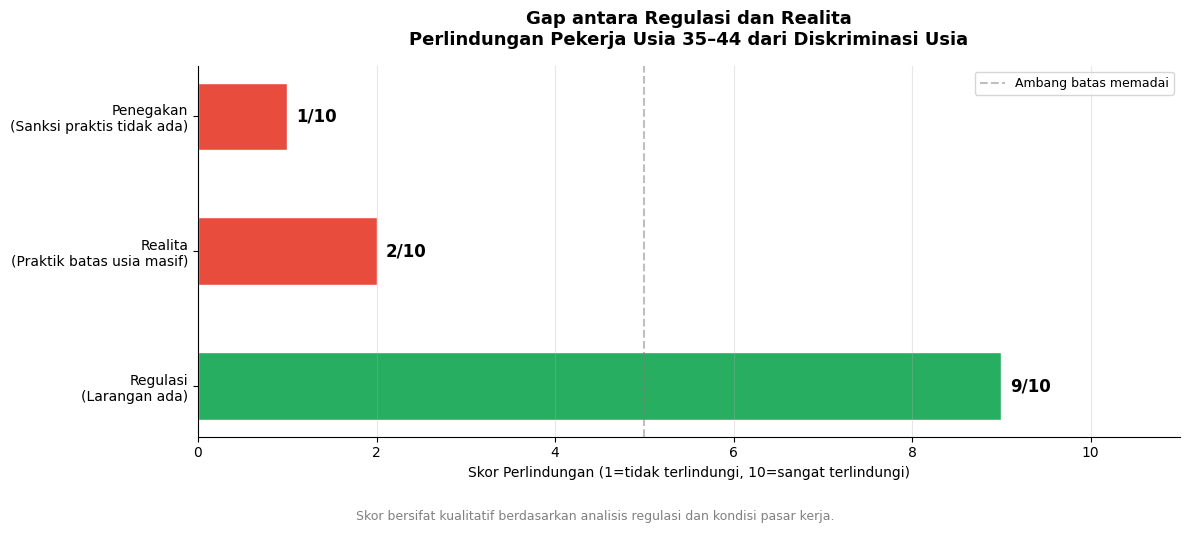

viz_03 tersimpan


In [12]:
# Visualisasi 3: Gap antara regulasi dan realita
fig, ax = plt.subplots(figsize=(12, 5))

kategori_gap = [
    'Regulasi\n(Larangan ada)',
    'Realita\n(Praktik batas usia masif)',
    'Penegakan\n(Sanksi praktis tidak ada)'
]
skor = [9, 2, 1]  # skala 1-10: seberapa "terlindungi" pekerja usia 35-44
warna_gap = ['#27AE60', '#E74C3C', '#E74C3C']

bars = ax.barh(kategori_gap, skor, color=warna_gap, edgecolor='white', height=0.5)
for bar, val in zip(bars, skor):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}/10', va='center', fontsize=12, fontweight='bold')

ax.set_xlim(0, 11)
ax.set_xlabel('Skor Perlindungan (1=tidak terlindungi, 10=sangat terlindungi)', fontsize=10)
ax.set_title(
    'Gap antara Regulasi dan Realita\nPerlindungan Pekerja Usia 35–44 dari Diskriminasi Usia',
    fontsize=13, fontweight='bold', pad=15
)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Ambang batas memadai')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.figtext(
    0.5, -0.05,
    'Skor bersifat kualitatif berdasarkan analisis regulasi dan kondisi pasar kerja.',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'viz_03_gap_regulasi_realita.png', dpi=150, bbox_inches='tight')
plt.show()
print('viz_03 tersimpan')

---
## Bagian 4: Analisis Upah — UMP vs Daya Beli Riil

In [13]:
# Data UMP DKI Jakarta 2021-2026 dan konteks ekonomi
ump_data = pd.DataFrame({
    'tahun': [2021, 2022, 2023, 2024, 2025, 2026],
    'ump_dki': [4416186, 4641854, 4901798, 5067381, 5396761, 5729876],
    'kenaikan_pct': [None, 5.1, 5.6, 3.4, 6.5, 6.17]
})

# Konteks: kebutuhan hidup layak versi serikat buruh
# Serikat buruh menuntut sekitar Rp 6 juta (2025)
kebutuhan_buruh_2025 = 6000000

# Estimasi biaya hidup minimum kepala keluarga dengan 2 tanggungan
# (kebutuhan individu UMP + kebutuhan 2 tanggungan @ 50%)
biaya_kk_2025 = 5396761 + (5396761 * 0.5 * 2)

print('=== TREN UMP DKI JAKARTA 2021–2026 ===')
for _, row in ump_data.iterrows():
    if pd.isna(row['kenaikan_pct']):
        naik = '-'
    else:
        naik = f"+{row['kenaikan_pct']:.1f}%"
    print(f"  {int(row['tahun'])} : Rp {int(row['ump_dki']):>10,} ({naik})")

print()
print('=== PERBANDINGAN UMP vs KEBUTUHAN RIIL (2025) ===')
print(f'  UMP DKI 2025 (individu)            : Rp {5396761:>10,}')
print(f'  Tuntutan serikat buruh (individu)  : Rp {kebutuhan_buruh_2025:>10,}')
print(f'  Est. kebutuhan KK (1+2 tanggungan) : Rp {biaya_kk_2025:>10,.0f}')
print(f'  Gap UMP vs kebutuhan KK            : Rp {biaya_kk_2025 - 5396761:>10,.0f}')
print()
print('Catatan: UMP secara hukum adalah upah minimum PER INDIVIDU,')
print('bukan per keluarga. Pekerja usia 35-44 umumnya memiliki tanggungan')
print('keluarga yang menjadikan UMP tidak mencukupi secara riil.')

=== TREN UMP DKI JAKARTA 2021–2026 ===
  2021 : Rp  4,416,186 (-)
  2022 : Rp  4,641,854 (+5.1%)
  2023 : Rp  4,901,798 (+5.6%)
  2024 : Rp  5,067,381 (+3.4%)
  2025 : Rp  5,396,761 (+6.5%)
  2026 : Rp  5,729,876 (+6.2%)

=== PERBANDINGAN UMP vs KEBUTUHAN RIIL (2025) ===
  UMP DKI 2025 (individu)            : Rp  5,396,761
  Tuntutan serikat buruh (individu)  : Rp  6,000,000
  Est. kebutuhan KK (1+2 tanggungan) : Rp 10,793,522
  Gap UMP vs kebutuhan KK            : Rp  5,396,761

Catatan: UMP secara hukum adalah upah minimum PER INDIVIDU,
bukan per keluarga. Pekerja usia 35-44 umumnya memiliki tanggungan
keluarga yang menjadikan UMP tidak mencukupi secara riil.


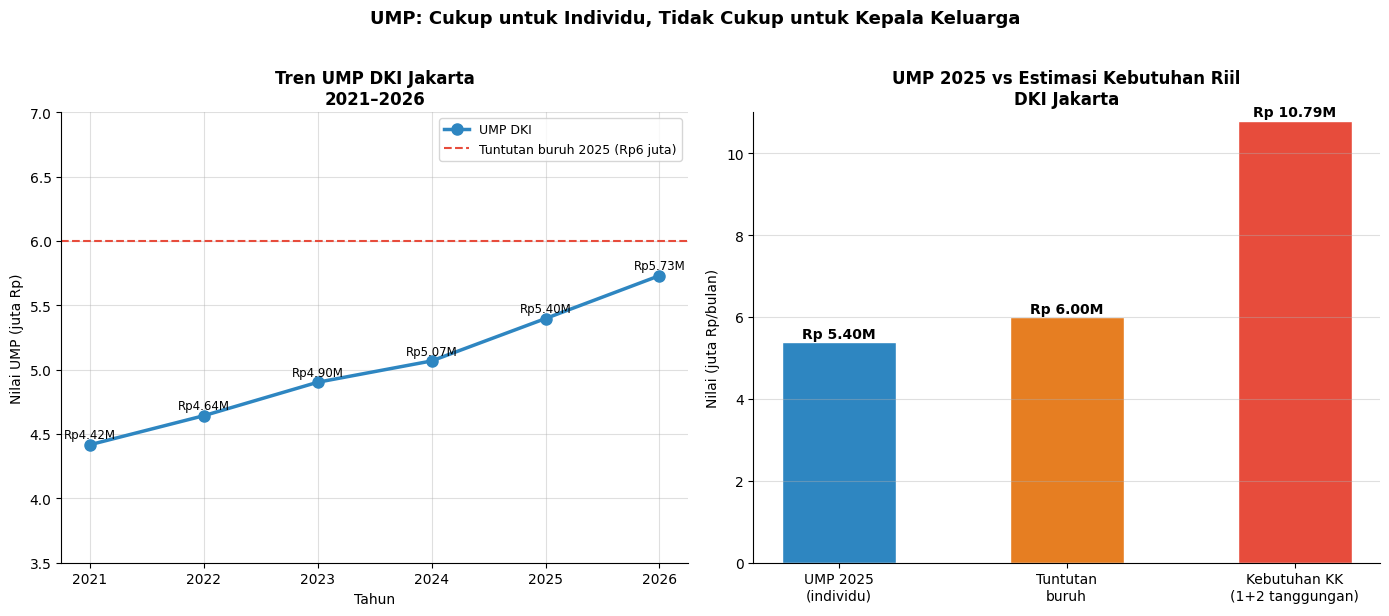

viz_04 tersimpan


In [14]:
# Visualisasi 4: Tren UMP vs kebutuhan riil
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel kiri: Tren UMP
axes[0].plot(ump_data['tahun'], ump_data['ump_dki'] / 1e6,
             'o-', color='#2E86C1', linewidth=2.5, markersize=8, label='UMP DKI')
for _, row in ump_data.iterrows():
    axes[0].text(row['tahun'], row['ump_dki']/1e6 + 0.05,
                 f"Rp{row['ump_dki']/1e6:.2f}M",
                 ha='center', fontsize=8.5)
axes[0].axhline(y=kebutuhan_buruh_2025/1e6, color='#E74C3C',
                linestyle='--', label=f'Tuntutan buruh 2025 (Rp6 juta)')
axes[0].set_title('Tren UMP DKI Jakarta\n2021–2026', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Nilai UMP (juta Rp)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.4)
axes[0].set_ylim(3.5, 7)

# Panel kanan: UMP vs kebutuhan berbagai skenario
skenario = ['UMP 2025\n(individu)', 'Tuntutan\nburuh', 'Kebutuhan KK\n(1+2 tanggungan)']
nilai = [5396761, 6000000, biaya_kk_2025]
warna_s = ['#2E86C1', '#E67E22', '#E74C3C']

bars = axes[1].bar(skenario, [v/1e6 for v in nilai],
                   color=warna_s, edgecolor='white', width=0.5)
for bar, val in zip(bars, nilai):
    axes[1].text(bar.get_x() + bar.get_width()/2, val/1e6 + 0.1,
                 f'Rp {val/1e6:.2f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('UMP 2025 vs Estimasi Kebutuhan Riil\nDKI Jakarta',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nilai (juta Rp/bulan)')
axes[1].set_ylim(0, 11)
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('UMP: Cukup untuk Individu, Tidak Cukup untuk Kepala Keluarga',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'viz_04_ump_vs_kebutuhan.png', dpi=150, bbox_inches='tight')
plt.show()
print('viz_04 tersimpan')

---
## Bagian 5: Analisis Historis — Daya Beli Upah dalam Standar Emas

> ⚠️ **Catatan metodologi:** Bagian ini menggunakan **gaji pokok PNS terendah** sebagai proxy standar upah minimum era Orde Baru, karena data UMR swasta 1993–1997 tidak tersedia secara digital. Sebagai abdi negara yang dibiayai dari penerimaan pajak, gaji pokok PNS dapat dipandang sebagai cerminan standar upah dasar yang ditetapkan negara pada masa itu.
>
> Harga emas menggunakan data historis Logam Mulia Antam. Analisis ini menyajikan **perspektif daya beli riil** — bukan dasar hukum penetapan upah.

In [17]:
# Load data historis gaji PNS vs emas
hist_raw = pd.read_csv(BASE_PATH + '/data/gaji_pns_vs_emas_1993_2025.csv')

print('=== DATA ERA ORDE BARU: GAJI PNS TERENDAH vs HARGA EMAS ===')
print('Sumber gaji : Peraturan Pemerintah (PP) resmi')
print('Sumber emas : Logam Mulia Antam')
print()

# Tampilkan era Orde Baru saja
orba = hist_raw[hist_raw['tahun'] <= 1997].copy()
print(orba[['tahun','gaji_pns_terendah_rp','dasar_hukum',
            'harga_emas_per_gram_rp','setara_gram_emas','keterangan']]
      .to_string(index=False))

print()
print('=== DATA PEMBANDING SAAT INI ===')
kini = hist_raw[hist_raw['tahun'] == 2025].copy()
print(kini[['tahun','harga_emas_per_gram_rp',
            'ump_dki_rp','setara_gram_emas_ump','keterangan']]
      .to_string(index=False))

=== DATA ERA ORDE BARU: GAJI PNS TERENDAH vs HARGA EMAS ===
Sumber gaji : Peraturan Pemerintah (PP) resmi
Sumber emas : Logam Mulia Antam

 tahun  gaji_pns_terendah_rp          dasar_hukum  harga_emas_per_gram_rp  setara_gram_emas                                keterangan
  1993               78000.0 PP No. 15 Tahun 1993                   24900              3.13 Kenaikan pertama setelah 16 tahun stagnan
  1994               78000.0 PP No. 15 Tahun 1993                   26875              2.90  Gaji tetap - emas naik - daya beli turun
  1995               78000.0 PP No. 15 Tahun 1993                   27850              2.80  Gaji tetap - emas naik - daya beli turun
  1996               78000.0 PP No. 15 Tahun 1993                   29850              2.61  Gaji tetap - emas naik - daya beli turun
  1997              135000.0  PP No. 6 Tahun 1997                   27100              4.98  Penyesuaian besar sebelum krisis moneter

=== DATA PEMBANDING SAAT INI ===
 tahun  harga_emas_per_

In [18]:
# Persiapan data untuk analisis
orba = hist_raw[hist_raw['tahun'] <= 1997].copy()

ump_2025        = 5396761
harga_emas_2025 = 2501000
gram_ump_2025   = ump_2025 / harga_emas_2025

gram_1993 = 78000  / 24900
gram_1994 = 78000  / 26875
gram_1995 = 78000  / 27850
gram_1996 = 78000  / 29850
gram_1997 = 135000 / 27100

print('=== RINGKASAN PERBANDINGAN DAYA BELI ===')
print()
print('ERA ORDE BARU — Gaji PNS Terendah (proxy standar upah negara):')
print(f'  1993 : Rp  78.000  = {gram_1993:.2f} gram emas  (PP No. 15/1993)')
print(f'  1994 : Rp  78.000  = {gram_1994:.2f} gram emas  (gaji tetap, emas naik)')
print(f'  1995 : Rp  78.000  = {gram_1995:.2f} gram emas  (gaji tetap, emas naik)')
print(f'  1996 : Rp  78.000  = {gram_1996:.2f} gram emas  (gaji tetap, emas naik)')
print(f'  1997 : Rp 135.000  = {gram_1997:.2f} gram emas  (PP No. 6/1997 — penyesuaian besar)')
print()
print('SAAT INI:')
print(f'  2025 : Rp 5.396.761 (UMP DKI) = {gram_ump_2025:.2f} gram emas')
print()
print('=== TEMUAN KUNCI ===')
print(f'UMP 2025 ({gram_ump_2025:.2f} gram) lebih rendah dari:')
print(f'  - Gaji PNS terendah 1993 ({gram_1993:.2f} gram)')
print(f'  - Gaji PNS terendah 1994 ({gram_1994:.2f} gram)')
print(f'  - Gaji PNS terendah 1995 ({gram_1995:.2f} gram)')
print(f'  Dan jauh di bawah penyesuaian 1997 ({gram_1997:.2f} gram)')


=== RINGKASAN PERBANDINGAN DAYA BELI ===

ERA ORDE BARU — Gaji PNS Terendah (proxy standar upah negara):
  1993 : Rp  78.000  = 3.13 gram emas  (PP No. 15/1993)
  1994 : Rp  78.000  = 2.90 gram emas  (gaji tetap, emas naik)
  1995 : Rp  78.000  = 2.80 gram emas  (gaji tetap, emas naik)
  1996 : Rp  78.000  = 2.61 gram emas  (gaji tetap, emas naik)
  1997 : Rp 135.000  = 4.98 gram emas  (PP No. 6/1997 — penyesuaian besar)

SAAT INI:
  2025 : Rp 5.396.761 (UMP DKI) = 2.16 gram emas

=== TEMUAN KUNCI ===
UMP 2025 (2.16 gram) lebih rendah dari:
  - Gaji PNS terendah 1993 (3.13 gram)
  - Gaji PNS terendah 1994 (2.90 gram)
  - Gaji PNS terendah 1995 (2.80 gram)
  Dan jauh di bawah penyesuaian 1997 (4.98 gram)


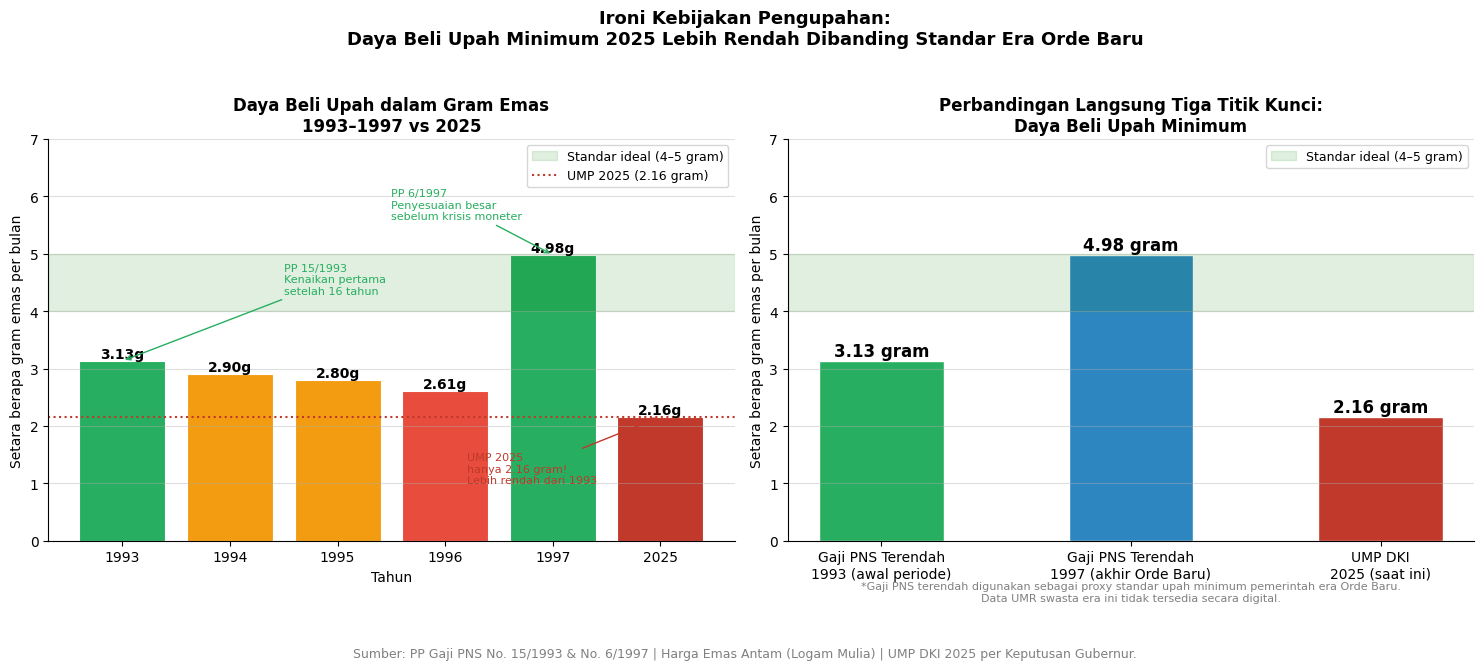

viz_05 tersimpan


In [19]:
# Visualisasi: Daya beli upah dalam gram emas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel kiri: Tren 1993-1997 + 2025 ---
tahun_plot = ['1993', '1994', '1995', '1996', '1997', '2025']
gram_plot  = [gram_1993, gram_1994, gram_1995, gram_1996, gram_1997, gram_ump_2025]
warna_plot = ['#27AE60','#F39C12','#F39C12','#E74C3C','#27AE60','#C0392B']

bars = axes[0].bar(tahun_plot, gram_plot,
                   color=warna_plot, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, gram_plot):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.05,
                 f'{val:.2f}g', ha='center', fontsize=10, fontweight='bold')

axes[0].axhspan(4, 5, alpha=0.12, color='green',
                label='Standar ideal (4–5 gram)')
axes[0].axhline(y=gram_ump_2025, color='#C0392B', linestyle=':',
                linewidth=1.5, label=f'UMP 2025 ({gram_ump_2025:.2f} gram)')

axes[0].annotate('PP 15/1993\nKenaikan pertama\nsetelah 16 tahun',
                 xy=(0, gram_1993), xytext=(1.5, 4.3),
                 arrowprops=dict(arrowstyle='->', color='#27AE60'),
                 fontsize=8, color='#27AE60')
axes[0].annotate('PP 6/1997\nPenyesuaian besar\nsebelum krisis moneter',
                 xy=(4, gram_1997), xytext=(2.5, 5.6),
                 arrowprops=dict(arrowstyle='->', color='#27AE60'),
                 fontsize=8, color='#27AE60')
axes[0].annotate(f'UMP 2025\nhanya {gram_ump_2025:.2f} gram!\nLebih rendah dari 1993',
                 xy=(5, gram_ump_2025), xytext=(3.2, 1.0),
                 arrowprops=dict(arrowstyle='->', color='#C0392B'),
                 fontsize=8, color='#C0392B')

axes[0].set_title('Daya Beli Upah dalam Gram Emas\n1993–1997 vs 2025',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Setara berapa gram emas per bulan')
axes[0].set_ylim(0, 7)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.4)

# --- Panel kanan: Perbandingan 3 titik kunci ---
titik_label = ['Gaji PNS Terendah\n1993 (awal periode)',
               'Gaji PNS Terendah\n1997 (akhir Orde Baru)',
               'UMP DKI\n2025 (saat ini)']
titik_gram  = [gram_1993, gram_1997, gram_ump_2025]
titik_warna = ['#27AE60', '#2E86C1', '#C0392B']

bars2 = axes[1].bar(titik_label, titik_gram,
                    color=titik_warna, edgecolor='white', width=0.5)
for bar, val in zip(bars2, titik_gram):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.08,
                 f'{val:.2f} gram', ha='center',
                 fontsize=12, fontweight='bold')

axes[1].axhspan(4, 5, alpha=0.12, color='green',
                label='Standar ideal (4–5 gram)')
axes[1].set_title('Perbandingan Langsung Tiga Titik Kunci:\nDaya Beli Upah Minimum',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Setara berapa gram emas per bulan')
axes[1].set_ylim(0, 7)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4)
axes[1].text(0.5, -0.15,
    '*Gaji PNS terendah digunakan sebagai proxy standar upah minimum pemerintah era Orde Baru.\n'
    'Data UMR swasta era ini tidak tersedia secara digital.',
    transform=axes[1].transAxes, ha='center', fontsize=8, color='gray')

plt.suptitle(
    'Ironi Kebijakan Pengupahan:\n'
    'Daya Beli Upah Minimum 2025 Lebih Rendah Dibanding Standar Era Orde Baru',
    fontsize=13, fontweight='bold', y=1.03)
plt.figtext(0.5, -0.05,
    'Sumber: PP Gaji PNS No. 15/1993 & No. 6/1997 | Harga Emas Antam (Logam Mulia) | '
    'UMP DKI 2025 per Keputusan Gubernur.',
    ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(OUTPUT_PATH + '/viz_05_daya_beli_emas_historis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('viz_05 tersimpan')


### Narasi Analitis

Sebagai abdi negara yang dibiayai dari penerimaan pajak, gaji pokok PNS dapat dipandang sebagai cerminan standar upah dasar yang ditetapkan negara. Data menunjukkan bahwa gaji pokok PNS golongan terendah pada periode 1993–1997 setara dengan **2,6 hingga 5,0 gram emas per bulan** — dengan penyesuaian besar pada 1997 melalui PP No. 6/1997 yang mengembalikannya ke kisaran 5 gram emas, tepat sebelum krisis moneter melanda.

Sebagai pembanding, UMP DKI Jakarta 2025 sebesar Rp 5,4 juta hanya setara **2,16 gram emas**. Artinya, dalam ukuran daya beli riil berbasis emas, standar upah saat ini berada di bawah standar upah dasar yang berlaku tiga dekade lalu — bahkan lebih rendah dari gaji PNS terendah tahun 1993.

Temuan ini mengindikasikan bahwa pertumbuhan upah nominal belum diimbangi dengan pemeliharaan daya beli riil — sebuah tantangan struktural dalam kebijakan pengupahan nasional yang perlu menjadi perhatian serius.

> *"Ada ironi yang layak direnungkan: pemerintah yang menggantikan Orde Baru justru menetapkan standar upah yang daya belinya lebih rendah dibanding rezim yang mereka tumbangkan — setidaknya dalam ukuran gram emas. Ini bukan tuduhan, melainkan cerminan dari data yang berbicara sendiri."* — Catatan Penulis

---
## Bagian 6: Proyeksi Dampak Jangka Panjang

In [20]:
# Skenario proyeksi dampak jika sistem batas usia dibiarkan

print('=== PROYEKSI DAMPAK JANGKA PANJANG ===')
print('Jika praktik diskriminasi usia dalam rekrutmen dibiarkan berlanjut:')
print()

dampak = {
    'Jangka Pendek (1-3 tahun)': [
        'Pengangguran tersembunyi usia 35-45 terus meningkat',
        'Pekerja terpaksa masuk sektor informal dengan upah jauh di bawah UMP',
        'Daya beli rumah tangga kelas menengah bawah menurun',
        'Risiko kemiskinan baru pada kelompok usia produktif matang'
    ],
    'Jangka Menengah (3-10 tahun)': [
        'Penurunan konsumsi domestik — mengancam pertumbuhan ekonomi',
        'Beban BPJS dan program perlindungan sosial meningkat',
        'Generasi berikutnya (anak) terdampak: putus sekolah, gizi buruk',
        'Brain drain keterampilan: pengalaman 35-45 tahun tidak terserap produktif'
    ],
    'Jangka Panjang (10-20 tahun)': [
        'Indonesia gagal memanfaatkan bonus demografi secara optimal',
        'Ketimpangan sosial melebar — Gini ratio naik',
        'Potensi instabilitas sosial: kelompok usia produktif tanpa penghasilan layak',
        'Kehilangan PDB potensial dari tenaga kerja berpengalaman yang tidak produktif'
    ]
}

for periode, item_list in dampak.items():
    print(f'📍 {periode}')
    for item in item_list:
        print(f'   • {item}')
    print()

=== PROYEKSI DAMPAK JANGKA PANJANG ===
Jika praktik diskriminasi usia dalam rekrutmen dibiarkan berlanjut:

📍 Jangka Pendek (1-3 tahun)
   • Pengangguran tersembunyi usia 35-45 terus meningkat
   • Pekerja terpaksa masuk sektor informal dengan upah jauh di bawah UMP
   • Daya beli rumah tangga kelas menengah bawah menurun
   • Risiko kemiskinan baru pada kelompok usia produktif matang

📍 Jangka Menengah (3-10 tahun)
   • Penurunan konsumsi domestik — mengancam pertumbuhan ekonomi
   • Beban BPJS dan program perlindungan sosial meningkat
   • Generasi berikutnya (anak) terdampak: putus sekolah, gizi buruk
   • Brain drain keterampilan: pengalaman 35-45 tahun tidak terserap produktif

📍 Jangka Panjang (10-20 tahun)
   • Indonesia gagal memanfaatkan bonus demografi secara optimal
   • Ketimpangan sosial melebar — Gini ratio naik
   • Potensi instabilitas sosial: kelompok usia produktif tanpa penghasilan layak
   • Kehilangan PDB potensial dari tenaga kerja berpengalaman yang tidak produkt

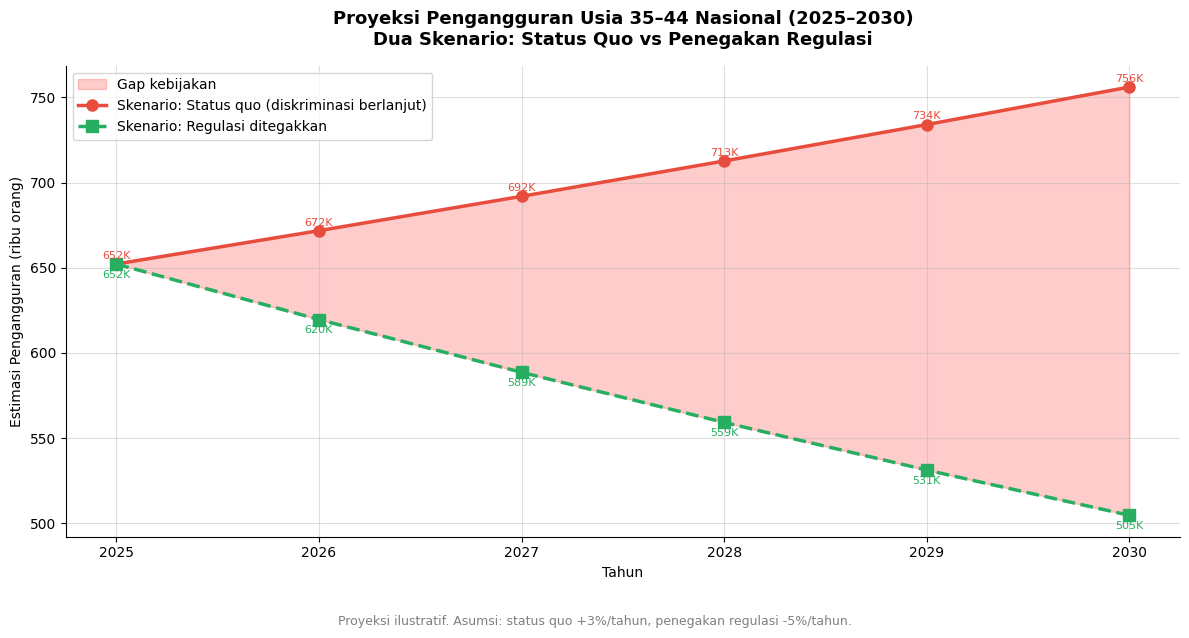

viz_06 tersimpan


In [21]:
# Visualisasi 6: Estimasi kehilangan output ekonomi
fig, ax = plt.subplots(figsize=(12, 6))

tahun_proyeksi = [2025, 2026, 2027, 2028, 2029, 2030]

# Skenario 1: Status quo (diskriminasi berlanjut)
# Asumsi: pengangguran usia 35-44 tumbuh 3% per tahun
pengangguran_base = est_total_3544
skenario_quo = [pengangguran_base * (1.03 ** i) for i in range(6)]

# Skenario 2: Regulasi ditegakkan
# Asumsi: pengangguran turun 5% per tahun
skenario_baik = [pengangguran_base * (0.95 ** i) for i in range(6)]

ax.fill_between(tahun_proyeksi,
                [v/1000 for v in skenario_baik],
                [v/1000 for v in skenario_quo],
                alpha=0.2, color='red', label='Gap kebijakan')
ax.plot(tahun_proyeksi, [v/1000 for v in skenario_quo],
        'o-', color='#E74C3C', linewidth=2.5, markersize=8,
        label='Skenario: Status quo (diskriminasi berlanjut)')
ax.plot(tahun_proyeksi, [v/1000 for v in skenario_baik],
        's--', color='#27AE60', linewidth=2.5, markersize=8,
        label='Skenario: Regulasi ditegakkan')

for i, (y1, y2) in enumerate(zip(skenario_quo, skenario_baik)):
    ax.text(tahun_proyeksi[i], y1/1000 + 3,
            f'{y1/1000:.0f}K', ha='center', fontsize=8, color='#E74C3C')
    ax.text(tahun_proyeksi[i], y2/1000 - 8,
            f'{y2/1000:.0f}K', ha='center', fontsize=8, color='#27AE60')

ax.set_title(
    'Proyeksi Pengangguran Usia 35–44 Nasional (2025–2030)\n'
    'Dua Skenario: Status Quo vs Penegakan Regulasi',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Tahun')
ax.set_ylabel('Estimasi Pengangguran (ribu orang)')
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
plt.figtext(
    0.5, -0.05,
    'Proyeksi ilustratif. Asumsi: status quo +3%/tahun, penegakan regulasi -5%/tahun.',
    ha='center', fontsize=9, color='gray'
)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'viz_06_proyeksi_dampak.png', dpi=150, bbox_inches='tight')
plt.show()
print('viz_06 tersimpan')

---
## Bagian 7: Opini Penulis

> *Bagian ini merupakan opini dan pengalaman empiris pribadi penulis sebagai pencari kerja usia 35+ yang aktif memonitor platform lowongan kerja. Bukan bagian dari analisis deskriptif, namun disertakan sebagai konteks sosial yang tidak bisa diabaikan.*

---

### Fenomena Batas Usia: Pengamatan Lapangan

Sebagai pencari kerja yang aktif membuka platform lowongan kerja, penulis secara langsung mengamati bahwa **diskriminasi usia bukan sekadar teori** — melainkan praktik yang berlangsung terang-terangan hingga saat ini.

Beberapa pola yang penulis temukan:

**1. Batas usia ekstrem di lowongan formal**\
Banyak perusahaan secara eksplisit mencantumkan batas usia maksimal yang sangat rendah — bahkan hingga **25 tahun** untuk posisi yang tidak memiliki tuntutan fisik khusus. Ini bukan lagi "preferensi" — ini diskriminasi sistemik yang bertentangan langsung dengan SE Menaker M/6/HK.04/V/2025.

**2. Motif ekonomi di balik diskriminasi usia**\
Penulis berpendapat bahwa praktik batas usia ekstrem ini didorong oleh satu motif utama: **menekan biaya tenaga kerja**. Tenaga kerja muda cenderung menerima gaji lebih rendah, belum memiliki banyak tuntutan, dan lebih mudah "dibentuk" sesuai keinginan pemberi kerja. Ini menjelaskan mengapa di era yang sama, makin banyak lowongan kerja yang menawarkan gaji **Rp 1–2 juta** — jauh di bawah UMP yang sudah di atas Rp 5 juta.

**3. Paradoks UMP**\
UMP yang kita kenal adalah **biaya hidup minimum per individu**. Sementara pekerja usia 35–45 umumnya adalah kepala keluarga dengan 2–3 tanggungan. Dengan kurs rupiah yang telah melemah ke kisaran Rp 16.000–18.000 per USD dan tekanan inflasi yang berkelanjutan, UMP aktual sudah tidak lagi merepresentasikan "hidup layak" yang diamanatkan UUD 1945.

**4. Standar emas sebagai cermin daya beli**\
Era Orde Baru memiliki kelemahan politiknya sendiri, namun dalam satu hal penetapan UMR yang setara 4–5 gram emas per bulan mencerminkan pendekatan yang lebih realistis terhadap daya beli. Dengan harga emas Antam 2025 di Rp 2,5 juta/gram, UMR yang setara dengan standar tersebut seharusnya berada di kisaran **Rp 10–12,5 juta** — dua kali lipat lebih dari UMP saat ini.

---

*Penulis menyadari bahwa pengalaman pribadi bukan pengganti data statistik yang representatif. Namun pengalaman empiris sebagai pelaku — bukan sekadar pengamat — memberikan dimensi kemanusiaan yang tidak selalu tertangkap oleh angka-angka BPS.*

---
## Bagian 8: Ringkasan & Rekomendasi

In [23]:
print('=' * 65)
print('           RINGKASAN TEMUAN UTAMA')
print('=' * 65)
print()
print('1. TPT USIA 35-44: KECIL PERSENTASENYA, BESAR DAMPAKNYA')
print(f'   TPT 35-39: 2,35% | TPT 40-44: 1,86%')
print(f'   Namun estimasi absolut nasional: ~{est_total_3544:,.0f} orang')
print()
print('2. REGULASI ADA — PENEGAKAN TIDAK ADA')
print('   UUD, UU Ketenagakerjaan, Konvensi ILO, dan SE Menaker')
print('   semuanya melarang diskriminasi usia.')
print('   Namun praktik batas usia ekstrem masih berlangsung terbuka.')
print()
print('3. UMP TIDAK CUKUP UNTUK KEPALA KELUARGA')
print(f'   UMP DKI 2025: Rp {ump_2025:,}')
print(f'   Estimasi kebutuhan KK (1+2 tanggungan): Rp {biaya_kk_2025:,.0f}')
print(f'   Gap: Rp {biaya_kk_2025 - ump_2025:,.0f}')
print()
print('4. DAYA BELI UMP MENURUN SECARA HISTORIS')
print(f'   UMP 2025 setara {ump_2025/harga_emas_2025:.2f} gram emas')
print(f'   Standar historis Orde Baru: 4–5 gram emas')

# Calculate umr_ideal_min and umr_ideal_max based on the ideal gold standard
umr_ideal_min = 4 * harga_emas_2025
umr_ideal_max = 5 * harga_emas_2025

print(f'   UMR ideal berbasis emas: Rp {umr_ideal_min:,}–Rp {umr_ideal_max:,}')
print()
print('5. PROYEKSI: STATUS QUO MEMPERBURUK KONDISI')
print('   Tanpa penegakan regulasi, pengangguran usia 35-44')
print('   diproyeksikan terus meningkat dalam 5 tahun ke depan.')
print()
print('=' * 65)
print()
print('REKOMENDASI KEBIJAKAN')
print('-' * 65)
rekomendasi = [
    'Perkuat SE Menaker menjadi Peraturan Menteri atau Peraturan Pemerintah'
    ' agar memiliki kekuatan hukum yang mengikat',
    'Berikan sanksi tegas bagi perusahaan yang mencantumkan'
    ' batas usia diskriminatif dalam lowongan kerja',
    'Evaluasi formula penetapan UMP dengan mempertimbangkan'
    ' beban keluarga, bukan hanya kebutuhan individu',
    'Rancang program pelatihan reskilling khusus untuk'
    ' pekerja usia 35-45 agar tetap kompetitif',
    'Dorong perusahaan menerapkan rekrutmen berbasis kompetensi,'
    ' bukan berbasis usia'
]
for i, r in enumerate(rekomendasi, 1):
    print(f'{i}. {r}')
    print()
print('=' * 65)
print()
print('Sumber data: BPS RI (2025-2026), Kemnaker, Logam Mulia Antam.')
print('Analisis bersifat deskriptif — tidak mengklaim hubungan kausalitas.')

           RINGKASAN TEMUAN UTAMA

1. TPT USIA 35-44: KECIL PERSENTASENYA, BESAR DAMPAKNYA
   TPT 35-39: 2,35% | TPT 40-44: 1,86%
   Namun estimasi absolut nasional: ~652,176 orang

2. REGULASI ADA — PENEGAKAN TIDAK ADA
   UUD, UU Ketenagakerjaan, Konvensi ILO, dan SE Menaker
   semuanya melarang diskriminasi usia.
   Namun praktik batas usia ekstrem masih berlangsung terbuka.

3. UMP TIDAK CUKUP UNTUK KEPALA KELUARGA
   UMP DKI 2025: Rp 5,396,761
   Estimasi kebutuhan KK (1+2 tanggungan): Rp 10,793,522
   Gap: Rp 5,396,761

4. DAYA BELI UMP MENURUN SECARA HISTORIS
   UMP 2025 setara 2.16 gram emas
   Standar historis Orde Baru: 4–5 gram emas
   UMR ideal berbasis emas: Rp 10,004,000–Rp 12,505,000

5. PROYEKSI: STATUS QUO MEMPERBURUK KONDISI
   Tanpa penegakan regulasi, pengangguran usia 35-44
   diproyeksikan terus meningkat dalam 5 tahun ke depan.


REKOMENDASI KEBIJAKAN
-----------------------------------------------------------------
1. Perkuat SE Menaker menjadi Peraturan Menteri 